# Práctica 1 - Juego de coordinación multi-acción (JCMA)

## Introducción

En esta práctica trabajaremos con un juego estático y simétrico en estrategias, donde dos jugadores eligen simultáneamente un número entero en el conjunto $S = \{0,1,2,3,4,5\}$. Si la suma de ambas elecciones no supera un umbral (5), cada jugador obtiene exactamente lo que ha pedido; si lo supera, ambos reciben 0. Este juego presenta múltiples equilibrios puros que maximizan el bienestar social, pero con distintos grados de equidad entre jugadores. Las estrategias son simétricas, en el sentido de que ambos jugadores comparten el mismo conjunto de acciones. Los resultados cuya suma es 5 son eficientes (maximizan la suma de pagos), pero reparten beneficios de forma desigual.

Más abajo encontrarás su definición formal y su matriz de pagos en forma normal, que usaremos como base para el análisis y la implementación.

## Descripción de la práctica

**¡Importante!** Revisa el juego de [Nicky Case](https://ncase.me/trust/) llamado *The Evolution of Trust* (~30min). Aunque originalmente sobre el Dilema del Prisionero Iterado (DPI), sus conceptos sobre cooperación, estrategias reactivas y dinámicas evolutivas son directamente aplicables a nuestro juego de suma limitada iterado.

En nuestro caso, el juego es simultáneo y repetido: en cada ronda, los jugadores eligen acciones sin conocer la del rival, pero con acceso al historial completo de interacciones pasadas. Esto introduce complejidades como coordinación implícita, retaliación y evolución de normas sociales, haciendo de este juego un "dilema más complejo" que el DPI clásico (más acciones, umbral de suma, y payoffs asimétricos en equidad).

La práctica tiene dos partes:
 - Parte 1: Montar la estructura computacional que permita simular torneos del juego de suma limitada iterado.
 - Parte 2: Diseñar una estrategia para un torneo de tres fases (enfrentamiento directo, evolutivo, y en ecosistema ampliado).

## Definición formal del JCMA

- Jugadores: P1, P2.
- Acciones posibles: $S = \{0,1,2,3,4,5\}$.
- Funciones de pago: sea $i$ la acción escogida por el jugador P1 y $j$ la acción escogida por el jugador P2, se define $u_1$ y $u_2$ como los pagos que obtiene el jugador P1 y P2 respectivamente:

$$
 u_1(i,j)=\begin{cases}
 i, & \text{si } i+j\le 5,\\
 0, & \text{si } i+j>5,
 \end{cases}
 \qquad
 u_2(i,j)=\begin{cases}
 j, & \text{si } i+j\le 5,\\
 0, & \text{si } i+j>5.
 \end{cases}
$$

Es decir cada jugador obtiene *"lo que pide"*, a no ser que la suma de lo que todos piden sea mayor que 5, en cuyo caso nadie gana nada.



## Matriz de pagos

Por filas la acción del jugador P1, por columnas la acción del jugador P2.

<center>

|   i\j |     0 |     1 |     2 |     3 |         4 |         5 |
| ----: | ----: | ----: | ----: | ----: | --------: | --------: |
| **0** | (0,0) | (0,1) | (0,2) | (0,3) |     (0,4) |     (0,5) |
| **1** | (1,0) | (1,1) | (1,2) | (1,3) |     (1,4) |   (0,0)   |
| **2** | (2,0) | (2,1) | (2,2) | (2,3) |   (0,0)   |   (0,0)   |
| **3** | (3,0) | (3,1) | (3,2) | (3,3) |   (0,0)   |   (0,0)   |
| **4** | (4,0) | (4,1) | (4,2) | (4,3) |   (0,0)   |   (0,0)   |
| **5** | (5,0) | (5,1) | (5,2) | (5,3) |   (0,0)   |   (0,0)   |


</center>


## Parte 1: Software para el estudio del JCMA

El primer objetivo es crear un software que permita simular torneos del juego definido arriba en las versiones "enfrentamiento directo" y  "evolutiva".

Requisitos mínimos:

- Programado en Python >3.8, utilizando programación orientada a objetos (OOP).
- Entradas para el torneo de enfrentamiento directo:
  - `all_players`: lista o tupla de jugadores participantes (con su estrategia).
  - `game`: objeto que define el juego (conjunto de acciones S={0..5}, umbral T=5 y función de pagos u1,u2).
  - `repetitions`: número de veces que una estrategia se enfrenta a otra.
  - `noise` (opcional): probabilidad de ejecución errónea de la acción elegida.
- Salidas: información (visual) del resultado del campeonato (ranking y puntuaciones agregadas).
- Incluir al menos estrategias básicas: `AlwaysK` para K∈{0,1,2,3,4,5} y `UniformRandom`. Debe ser sencillo añadir nuevas estrategias.

Estructura de proyecto recomendada (solo si piensas trabajar en local, si usas este notebook como lugar de trabajo, ignórala):

```
.
└── limited_sum/
    ├── limited_sum/
    │   ├── __init__.py
    │   ├── game.py        # define S, T y la función de pagos u1,u2
    │   ├── player.py      # clase base Player y estrategias básicas (AlwaysK, Random)
    │   ├── match.py       # partida one-shot entre dos jugadores y registro de payoffs
    │   ├── tournament.py  # lógica del torneo todos-contra-todos
    │   └── evolution.py   # dinámica evolutiva
    ├── main.py
    └── ...
```

### Plantilla de desarrollo

A continuación se propone una **plantilla de desarrollo** con los módulos/clases que se recomienda implementar para resolver este problema. No es obligatorio seguir esta estructura, pero a falta de mejores ideas, puede ser un buen punto de partida.

Para facilitar la tarea de identificar qué métodos faltan por implementar, en todos ellos se ha incluido la excepción ```raise NotImplementedError``` para poner de manifiesto que dicho método debe ser implementado.

El uso de librerías **basicas** está permitido, siempre que esté justificado.


In [2]:
from abc import ABC, abstractmethod
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
import itertools
import random
from typing import Self, Sequence


#### El módulo ```game```

El primer módulo que se recomienda implementar es el que recoge la información sobre el juego. Como nuestro juego tiene 6 acciones posibles (0 a 5), por simplicidad crearemos constantes para representarlas. El umbral de suma es THRESHOLD=5. Representarán estas acciones a lo largo de todo el código:

In [3]:
# Acciones del juego de suma limitada
ACTIONS = (0, 1, 2, 3, 4, 5)
THRESHOLD = 5  # Umbral de suma

Ahora se propone implementar una clase llamada ```Game``` para representar el juego de suma limitada.

In [4]:
class Game():

    def __init__(self, actions: tuple[int, ...] = ACTIONS, threshold: int = THRESHOLD):
        """
        Represents the limited-sum game.

        Parameters:
            - actions (list[int]): list of possible actions (default: [0,1,2,3,4,5])
            - threshold (int): sum threshold beyond which both get 0 (default: 5)
        """
        self.actions = actions
        self.threshold = threshold

    @property
    def payoff_matrix(self) -> tuple[np.ndarray, np.ndarray]:
        """
        Payoff matrix of the game.

        Returns:
            - 6x6 np array of the matrix
        """
        size = len(self.actions)
        matrix_p1 = np.zeros((size, size), dtype=int)
        matrix_p2 = np.zeros((size, size), dtype=int)
        for i, a_1 in enumerate(self.actions):
            for j, a_2 in enumerate(self.actions):
                payoff_p1, payoff_p2 = self.evaluate_result(a_1, a_2)
                matrix_p1[i, j] = payoff_p1
                matrix_p2[i, j] = payoff_p2
        return matrix_p1, matrix_p2

    def evaluate_result(self, a_1: int, a_2: int) -> tuple[int, int]:
        """
        Given two actions, returns the payoffs of the two players.

        Parameters:
            - a_1 (int): action of player 1 (0 to 5)
            - a_2 (int): action of player 2 (0 to 5)

        Returns:
            - tuple of two ints, being the first and second values the payoff
            for the first and second player, respectively.
        """
        return (a_1, a_2) if (a_1 + a_2) <= self.threshold else (0, 0)


Comprueba que los métodos anteriores funcionan correctamente con el siguiente test:

In [5]:
# Prints all possible outcomes of the limited-sum game
game = Game()
possible_actions = ACTIONS
for a1, a2 in itertools.product(possible_actions, repeat=2):
    print(f"{(a1, a2)} -> {game.evaluate_result(a1, a2)}")

game.payoff_matrix

# Output:
# (0, 0) -> (0, 0)
# (0, 1) -> (0, 1)
# ...
# (5, 5) -> (0, 0)

(0, 0) -> (0, 0)
(0, 1) -> (0, 1)
(0, 2) -> (0, 2)
(0, 3) -> (0, 3)
(0, 4) -> (0, 4)
(0, 5) -> (0, 5)
(1, 0) -> (1, 0)
(1, 1) -> (1, 1)
(1, 2) -> (1, 2)
(1, 3) -> (1, 3)
(1, 4) -> (1, 4)
(1, 5) -> (0, 0)
(2, 0) -> (2, 0)
(2, 1) -> (2, 1)
(2, 2) -> (2, 2)
(2, 3) -> (2, 3)
(2, 4) -> (0, 0)
(2, 5) -> (0, 0)
(3, 0) -> (3, 0)
(3, 1) -> (3, 1)
(3, 2) -> (3, 2)
(3, 3) -> (0, 0)
(3, 4) -> (0, 0)
(3, 5) -> (0, 0)
(4, 0) -> (4, 0)
(4, 1) -> (4, 1)
(4, 2) -> (0, 0)
(4, 3) -> (0, 0)
(4, 4) -> (0, 0)
(4, 5) -> (0, 0)
(5, 0) -> (5, 0)
(5, 1) -> (0, 0)
(5, 2) -> (0, 0)
(5, 3) -> (0, 0)
(5, 4) -> (0, 0)
(5, 5) -> (0, 0)


(array([[0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 0],
        [2, 2, 2, 2, 0, 0],
        [3, 3, 3, 0, 0, 0],
        [4, 4, 0, 0, 0, 0],
        [5, 0, 0, 0, 0, 0]]),
 array([[0, 1, 2, 3, 4, 5],
        [0, 1, 2, 3, 4, 0],
        [0, 1, 2, 3, 0, 0],
        [0, 1, 2, 0, 0, 0],
        [0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0]]))

#### El módulo ```player```

Ahora vamos a programar un módulo que sirva para representar a los jugadores. En particular, su método principal será ```strategy()```, que devolverá una acción a realizar, en base a la historia de interacción con otro jugador. Además, aprovecharemos a implementar estrategias básicas, para que luego sea sencillo hacer pruebas. Algunas de estas estrategias tienen soluciones abiertas: por el momento, implementa lógicas sencillas, ya que estas estrategias se usarán para testeo exclusivamente.

Empezaremos programando una clase abstracta llamada ```Player``` de la que heredarán los jugadores concretos que programaremos a continuación.

In [6]:
class Player(ABC):

    @abstractmethod
    def __init__(self, game: Game, name: str = ""):
        """
        Abstract class that represents a generic player

        Parameters:
            - name (str): the name of the strategy
            - game (Game): the game that this player will play
        """

        self.name = name
        self.game = game

        self.history  = []  # This is the main variable of this class. It is
                            # intended to store all the history of actions
                            # performed by this player.
                            # Example: [0, 1, 2, 3] <- So far, the
                            # interaction lasts four rounds. In the first one,
                            # this player chose 0. In the second, 1. Etc.

    @abstractmethod
    def strategy(self, opponent: Self) -> int:
        """
        Main call of the class. Gives the action for the following round of the
        interaction, based on the history

        Parameters:
            - opponent (Player): is another instance of Player.

        Results:
            - An integer representing the action (0 to 5)
        """
        pass

    def compute_scores(self, opponent, action_self: int | None = None,
                       action_opponent: int | None = None) -> tuple[float, float]:
        """
        Compute the scores for a given opponent and introduces the respective
        actions into the respective histories of both players.

        Parameters:
            - opponent (Player): is another instance of Player.

        Results:
            - A tuple of two floats, where the first value is the current
            player's payoff, and the second value is the opponent's payoff.
        """
        # Get the actions of each player according to their strategies if not given:
        if action_self is None:
            action_self = self.strategy(opponent)
        if action_opponent is None:
            action_opponent = opponent.strategy(self)

        # Update their histories:
        self.history.append(action_self)
        opponent.history.append(action_opponent)

        # Return the score:
        return self.game.evaluate_result(action_self, action_opponent)

    def clean_history(self):
        """Resets the history of the current player"""
        self.history = []


# The basic strategies for the limited-sum game are represented below:

class Always0(Player):

    def __init__(self, game: Game, name: str = "always_0"):
        """Always chooses 0"""
        super().__init__(game, name)

    def strategy(self, opponent: Player) -> int:
        """Always chooses 0"""
        return 0


class Always3(Player):

    def __init__(self, game: Game, name: str = "always_3"):
        """Always chooses 3"""
        super().__init__(game, name)

    def strategy(self, opponent: Player) -> int:
        """Always chooses 3"""
        return 3


class UniformRandom(Player):

    def __init__(self, game: Game, name: str = "uniform_random"):
        """Chooses uniformly at random"""
        super().__init__(game, name)

    def strategy(self, opponent: Player) -> int:
        """Chooses uniformly at random"""
        return np.random.choice(self.game.actions)


class Focal5(Player):

    def __init__(self, game: Game, name: str = "focal_5"):
        """Tries to coordinate on i+j=threshold"""
        super().__init__(game, name)

    def strategy(self, opponent: Player) -> int:
        """First round: threshold // 2, then adapts based on opponent trying to maximize the
        chances of establishing a 5-way split in each round by returning the difference
        between the threshold and the last number returned by the opponent"""
        return self.game.threshold // 2 if opponent.history == [] else (self.game.threshold - opponent.history[-1])


class TitForTat(Player):

    def __init__(self, game: Game, name: str = "tit_for_tat"):
        """Tit-for-tat adapted to the JCMA."""
        super().__init__(game, name)

    def strategy(self, opponent: Player) -> int:
        """Similar to Focal5, but reactive with opponent's actions above threshold // 2,
        in which case he will mirror the opponent's action."""
        if opponent.history == []:
            return self.game.threshold // 2
        else:
            return opponent.history[-1] if opponent.history[-1] > (self.game.threshold // 2) \
                else (self.game.threshold - opponent.history[-1])


Testearemos este módulo una vez programemos el siguiente

#### El módulo ```match```

Ya sabemos manejar jugadores. Ahora vamos a enfrentarles. El presente módulo pretende recoger las herramientas necesarias para enfrentar a dos jugadores en una *partida* del JCMA. Está compuesto por una clase llamada ```Match``` que implementa el método principal ```play()```. Incluye el mecanismo de *"error"*: aleatoriamente para cada jugador y ronda, con una cierta probabilidad `error`, la acción del jugador $a$ será cambiada por su complementaria:
 - 0 ↔ 5
 - 1 ↔ 4
 - 2 ↔ 3
 - 3 ↔ 2
 - 4 ↔ 1
 - 5 ↔ 1

In [7]:
class Match():

    def __init__(self, player_1: Player,
                       player_2: Player,
                       n_rounds: int = 100,
                       error: float = 0.0):
        """
        Match class to represent an iterative limited-sum game

        Parameters:
            - player_1 (Player): first player of the match
            - player_2 (Player): second player of the match
            - n_rounds (int = 100): number of rounds in the match
            - error (float = 0.0): error probability (on a 0-1 scale).
        """

        assert n_rounds > 0, "'n_rounds' should be greater than 0"

        self.player_1 = player_1
        self.player_2 = player_2
        self.n_rounds = n_rounds
        self.error = error

        self.score = [0, 0]  # this variable will store the final result of
                                 # the match, once the 'play()' function has
                                 # been called. The two values of the tuple
                                 # correspond to the points scored by the first
                                 # and second player, respectively.

    def complementary(self, n: int) -> int:
        '''Returns the complementary of an action.
        For example, in case of being in a 0-5 actions,
        1 will return 4 or 3 will return 2 '''
        return max(self.player_1.game.actions) - n

    def play(self, do_print: bool = False) -> None:
        """
        Main call of the class. Play the match.
        Stores the final result in 'self.score'

        Parameters
            - do_print (bool = False): if True, should print the ongoing
            results at the end of each round (i.e. print round number, last
            actions of both players and ongoing score).
        """
        # Clean the histories:
        self.player_1.clean_history()
        self.player_2.clean_history()

        for _ in range(self.n_rounds):

            # Receive the respective strategies:
            strategy_p1 = self.player_1.strategy(self.player_2)
            strategy_p2 = self.player_2.strategy(self.player_1)

            # Apply the possible error by calling the complementary function:
            if np.random.rand() < self.error:
                strategy_p1 = self.complementary(strategy_p1)
                if do_print:
                    print(f'Error of {self.player_1.name}!\n')
            if np.random.rand() < self.error:
                strategy_p2 = self.complementary(strategy_p2)
                if do_print:
                    print(f'Error of {self.player_2.name}!\n')

            # Final score:
            score = self.player_1.compute_scores(self.player_2, strategy_p1, strategy_p2)

            # Update the score:
            self.score[0] += score[0]
            self.score[1] += score[1]

            # Print if indicated:
            if do_print:
                print(f'    Round {_}: {strategy_p1} vs {strategy_p2} --> {score}, score: {self.score}\n')

Comprueba que los últimos dos módulos funcionan como se espera en la siguiente celda. Experimenta con distintas combinaciones de jugadores y observa que los resultados son los esperados. Por ejemplo, un Always0 y un Focal5 deberían coordinarse en (0,5) tras la primera ronda, obteniendo 0 y 5 puntos respectivamente por ronda. Comprueba también que el error se está tratando como corresponde. Por ejemplo, fíjalo en un valor alto (e.g. 0.2) y observa cómo las acciones pueden cambiar aleatoriamente. Comprueba también que puedes enfrentar dos jugadores que jueguen la misma estrategia (simplemente crea dos instancias del mismo jugador, con distintos nombres).

In [8]:
game = Game()

always0_player = Always0(game, "always0")
always3_player = Always3(game, "always3")
random_player = UniformRandom(game, "random")
focal5_player = Focal5(game, "focal5")
tft_player = TitForTat(game, "tft")

focal5_player_2 = Focal5(game, "focal5_2")

match = Match(focal5_player, focal5_player_2, n_rounds=10, error=0.2)
match.play(do_print=True)

    Round 0: 2 vs 2 --> (2, 2), score: [2, 2]

    Round 1: 3 vs 3 --> (0, 0), score: [2, 2]

    Round 2: 2 vs 2 --> (2, 2), score: [4, 4]

    Round 3: 3 vs 3 --> (0, 0), score: [4, 4]

    Round 4: 2 vs 2 --> (2, 2), score: [6, 6]

    Round 5: 3 vs 3 --> (0, 0), score: [6, 6]

Error of focal5!

    Round 6: 3 vs 2 --> (3, 2), score: [9, 8]

    Round 7: 3 vs 2 --> (3, 2), score: [12, 10]

    Round 8: 3 vs 2 --> (3, 2), score: [15, 12]

    Round 9: 3 vs 2 --> (3, 2), score: [18, 14]



#### El módulo ```tournament```

Finalmente, llegamos al módulo que nos va a permitir simular el campeonato.

In [9]:
class Tournament():

    def __init__(self, players: tuple[Player, ...],
                       n_rounds: int = 100,
                       error: float = 0.0,
                       repetitions: int = 2):
        """
        All-against-all tournament

        Parameters:
            - players (tuple[Player, ...]): tuple of players that will play the tournament
            - n_rounds (int = 100): number of rounds in each match
            - error (float = 0.0): error probability (in base 1)
            - repetitions (int = 2): number of matches each player plays against each other player
        """

        self.players = players
        self.n_rounds = n_rounds
        self.error = error
        self.repetitions = repetitions

        # This is a key variable of the class. It is intended to store the
        # ongoing ranking of the tournament. It is a dictionary whose keys are
        # the players in the tournament, and its corresponding values are the
        # points obtained in their interactions with each other. In the end, to
        # see the winner, it will be enough to sort this dictionary by the
        # values.
        self.ranking = {player: 0 for player in self.players}  # initial values

    def sort_ranking(self) -> None:
        """Sort the ranking by the value (score)"""
        self.ranking = dict(sorted(self.ranking.items(), key=lambda x: x[1]))

    def play(self) -> None:
        """
        Main call of the class. It must simulate the championship and update
        the variable 'self.ranking' with the accumulated points obtained by
        each player in their interactions.
        """
        for p1, p2 in itertools.combinations(self.players, 2): # Iterate throught all unique pairs of players.
            for _ in range(self.repetitions): # In order to prevent random result due to possible errors, it will be made a determined number of repetitions of all matches.

                # Clean both histories:
                p1.clean_history()
                p2.clean_history()

                # Play the match:
                match = Match(p1, p2, self.n_rounds, self.error)
                match.play()

                # Update ranking:
                self.ranking[p1] += match.score[0]
                self.ranking[p2] += match.score[1]

        # Sort ranking at the end
        self.sort_ranking()

    def plot_results(self):
        """
        Plots a bar chart of the final ranking. On the x-axis should appear
        the names of the sorted ranking of players participating in the
        tournament. On the y-axis the points obtained.
        """
        x = [player.name for player in self.ranking.keys()]
        y = list(self.ranking.values())

        plt.figure(figsize=(8, 4))
        plt.bar(x, y)

        plt.xlabel("Players")
        plt.ylabel("Total Score")
        plt.title("Tournament Results")

        # Methods for esthetic purposes:
        plt.xticks(rotation=45)
        plt.tight_layout()

        plt.show()


Para testear la implementación, prueba un torneo con las estrategias básicas del juego de suma limitada. Por ejemplo, con 10 rondas por interacción y sin error. Observa cómo diferentes estrategias obtienen diferentes puntuaciones según su capacidad para coordinarse en equilibrios eficientes o explotar a rivales cooperativos.

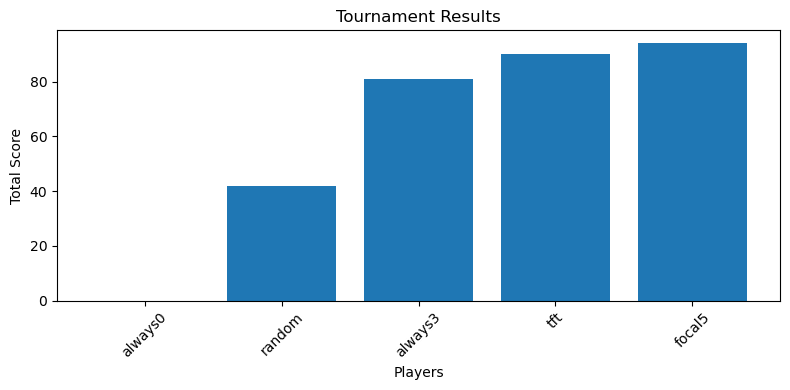

{<__main__.Always0 at 0x20a598d7250>: 0,
 <__main__.UniformRandom at 0x20a598d74d0>: np.int64(42),
 <__main__.Always3 at 0x20a598d7390>: 81,
 <__main__.TitForTat at 0x20a598d7750>: np.int64(90),
 <__main__.Focal5 at 0x20a598d7610>: np.int64(94)}

In [10]:
game = Game()

always0_player = Always0(game, "always0")
always3_player = Always3(game, "always3")
random_player = UniformRandom(game, "random")
focal5_player = Focal5(game, "focal5")
tft_player = TitForTat(game, "tft")

all_players = (always0_player, always3_player, random_player, focal5_player,
               tft_player)

tournament = Tournament(all_players, n_rounds=10, error=0.0, repetitions=1)
tournament.play()
tournament.plot_results()

tournament.ranking

#### El módulo ```evolution```

A continuación se presenta la variante evolutiva del torneo, similar a la que se explica en la sección "4. Repeated Tournament" del juego de Nicky Case. Este módulo necesitará de inputs extra. Ten en cuenta lo siguiente:
 - La población inicial de jugadores no es directamente el input de jugadores que dé el usuario, sino que cada jugador tiene varios "individuos" o "réplicas" que jugarán su estrategia. El usuario podrá definir la población inicial de dos opciones (ambos mecanismos deben ser funcionales en tu implementación):
   - Si el usuario define el tamaño de la población total (```int```), se asume que cada jugador comienza con el mismo número de representantes. Divide ese número entre el número de jugadores (redondeado al entero más próximo) y así obtendrás el número de individuos inicial de cada estrategia.
   - Si el usuario define una tupla de números de individuos (```list[int, ...]```), se asume que cada jugador tendrá el número de representantes que indique su índice dentro de dicha tupla.
 - Hay dos parámetros más que controlan el proceso evolutivo.
   - En primer lugar, el porcentaje de individuos que se desea incluir en la selección natural tras cada ronda; esto es, el número de individuos *de la parte de abajo del ranking* que se van a eliminar y sustituir por los *individuos de la parte de arriba* (en caso de empate entre individuos, escoge al azar).
   - En segundo lugar, el número de generaciones que se van a simular. Una generación es básicamente un "Torneo de enfrentamiento directo" + un "Proceso de selección natural".

El resto de decisiones de diseño que debas tomar son libres. A continuación se incluye la plantilla de desarrollo sugerida.

In [11]:
class Evolution():

    def __init__(self, players: tuple[Player, ...],
                       n_rounds: int = 100,
                       error: float = 0.0,
                       repetitions: int = 2,
                       generations: int = 100,
                       reproductivity: float = 0.05,
                       initial_population: tuple[int, ...] | int = 100):
        """
        Evolutionary tournament

        Parameters:
            - players (tuple[Player, ...]): tuple of players that will play the
         tournament
            - n_rounds (int = 100): number of rounds in each game
            - error (float = 0.0): error probability (in base 1)
            - repetitions (int = 2): number of games each player plays against
         the rest
            - generations (int = 100): number of generations to simulate
            - reproductivity (float = 0.05): ratio (base 1) of worst players
         that will be removed and substituted by the top ones in the natural
         selection process carried out at the end of each generation
            - initial_population (tuple[int, ...] | int = 100): list of
         individuals representing each players (same index as 'players' tuple)
         OR total population size (int).
        """

        self.players = players
        self.n_rounds = n_rounds
        self.error = error
        self.repetitions = repetitions
        self.generations = generations
        self.reproductivity = reproductivity

        if isinstance(initial_population, int):
            self.initial_population = [math.floor(initial_population
                                       / len(self.players))
                                       for _ in range(len(self.players))]
        else:
            self.initial_population = initial_population

        self.total_population = sum(self.initial_population)
        self.repr_int = int(self.total_population * self.reproductivity)

        self.ranking = {copy.deepcopy(player): 0 for i, player in
                        enumerate(self.players)
                        for _ in range(self.initial_population[i])}

    def natural_selection(self, result_tournament: dict[Player, int]) -> dict[Player, int]:
        """
        Kill the worst guys, reproduce the top ones. Takes the ranking once a
        face-to-face tournament has been played and returns another ranking,
        with the evolutionary changes applied

        Parameters:
            - result_tournament: the 'tournament.ranking' kind of sorted dict.

        Results:
            - Same kind of dict ranking as the input, but with the evolutionary
         dynamics applied
        """
        # Delete the last players:
        for player in list(result_tournament.keys())[:self.repr_int]:
            del result_tournament[player]

        # Append the new players:
        for player in list(result_tournament.keys())[-self.repr_int:]:
            result_tournament[copy.deepcopy(player)] = 0

        return result_tournament

    def count_strategies(self) -> dict[str, int]:
        """
        Counts the number of played alive of each strategy, based on the
        initial list of players. Should be computed analyzing the
        'self.ranking' variable. Useful for the results plot/print (not needed
        for the tournament itself)

        Results:
            - A dict, containing as keys the name of the players and as
         values the number of individuals they have now alive in the tournament
        """
        counts = {}
        for player in self.ranking.keys():
            name = player.name
            counts[name] = counts.get(name, 0) + 1
        return counts

    def play(self, do_print: bool = False):
        """
        Main call of the class. Performs the computations to simulate the
        evolutionary tournament.

        Parameters
            - do_print (bool = False): if True, should print the ongoing
         results at the end of each generation (i.e. print generation number,
         and number of individuals playing each strategy).
        """
        # Variable which shows the evolution of the number of individuals
        # of each player during each generation:

        count_evolution = {player.name: [val] for player, val in
                             zip(self.players, self.initial_population)}

        for generation in range(1, self.generations + 1):
            # Create and play each tournament, receiving the respective ranking
            # and updating it with natural_selection:
            tournament = Tournament(tuple(self.ranking.keys()), self.n_rounds, self.error, self.repetitions)
            tournament.play()
            self.ranking = self.natural_selection(tournament.ranking)

            # Append the new counts of individuals in the count_evolution dict
            # based on the values recieved by count_strategies():
            counts = self.count_strategies()
            for player_name in count_evolution.keys():
                count_evolution[player_name].append(counts.get(player_name, 0))

            if do_print:
                print(f'    Generation number {generation}: {counts}.\n')

        return count_evolution

    def stackplot(self, count_evolution: dict[str, list]) -> None:
        """
        Plots a 'stackplot' of the evolution of the tournament

        Parameters:
            - count_evolution (dict[Player, list]): a dictionary containing as
         keys the name of the strategies of the different players of the
         tournament. Each value is a list, where the 'i'-th position of that
         list indicates the number of individuals that player has at the end of
         the 'i'-th generation
         """

        COLORS = ['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black']

        for i, name in enumerate(count_evolution.keys()):
            plt.plot([], [], label=name, color=COLORS[(i) % len(COLORS)])

        plt.stackplot(list(range(self.generations + 1)),
                      np.array(list(count_evolution.values())), colors=COLORS)

        plt.legend()
        plt.show()

Para testear el módulo anterior, puedes experimentar con diferentes poblaciones iniciales de estrategias. Por ejemplo, un torneo evolutivo con estrategias Always0, UniformRandom y Focal5, sin error, con 10 rondas por interacción, con una reproductividad del 0.2. Observa qué estrategias dominan la población a lo largo de las generaciones:

    Generation number 1: {'always0': 10, 'random': 5, 'focal5': 10}.

    Generation number 2: {'always0': 5, 'random': 5, 'focal5': 15}.

    Generation number 3: {'random': 5, 'focal5': 20}.

    Generation number 4: {'focal5': 22, 'random': 3}.

    Generation number 5: {'focal5': 24, 'random': 1}.

    Generation number 6: {'focal5': 23, 'random': 2}.

    Generation number 7: {'random': 1, 'focal5': 24}.

    Generation number 8: {'random': 1, 'focal5': 24}.

    Generation number 9: {'focal5': 24, 'random': 1}.

    Generation number 10: {'focal5': 23, 'random': 2}.



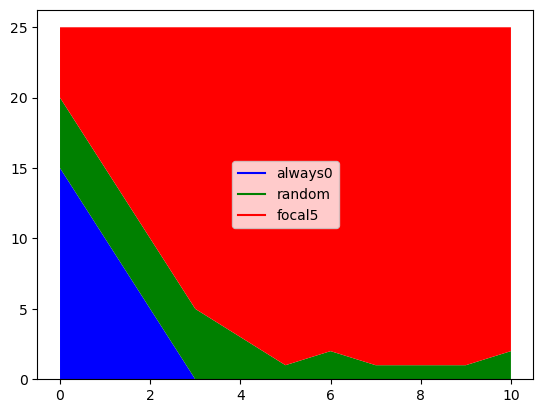

In [12]:
game = Game()

always0_player = Always0(game, "always0")
random_player = UniformRandom(game, "random")
focal5_player = Focal5(game, "focal5")

all_players = (always0_player, random_player, focal5_player)

evolution = Evolution(all_players, n_rounds=10, error=0.00,
                      repetitions=1, generations=10, reproductivity=0.2,
                      initial_population=(15, 5, 5))

count_evolution = evolution.play(True)
evolution.stackplot(count_evolution=count_evolution)

¡Enhorabuena! La primera parte de la práctica ya la has terminado. Ahora puedes experimentar todo lo que quieras con el juego de suma limitada iterado. Tú mismo has creado la herramienta para hacerlo. En la siguiente sección, tendrás que diseñar una estrategia para participar en un triple campeonato.

## Parte 2: diseño de una estrategia

A continuación deberás implementar una estrategia que se enfrentará a las de tus compañeros en un torneo del JCMA.

Los juegos contra tus rivales tendrán un final **no determinista**. Esto quiere decir que el número de rondas que se van a jugar no se sabe con precisión. En lugar de eso, después de cada ronda, la partida tiene una cierta probabilidad de acabar (pequeña). ¿Por qué haremos esto? En juegos iterados con duración finita conocida, la proximidad del final juega un papel crucial en las decisiones estratégicas (e.g., incentivos a desertar en las últimas rondas).

Con el objetivo de dejar esta complejidad adicional fuera, jugaremos un número de rondas aleatorio: puedes pensar que tu estrategia va a jugar "muchas veces" contra cada rival. **En media, se jugarán 100 rondas** (puedes quedarte con ese número). Los puntos obtenidos en cada interacción se normalizarán por el número de rondas jugadas para evitar sesgos por duración variable.

### Descripción del campeonato
Ahora sí, vamos a ver las condiciones del torneo. Hay tres fases en esta competición:
 - Fase de enfrentamiento directo entre estrategias
 - Fase evolutiva
 - Fase evolutiva dentro del ecosistema completo del juego de suma limitada


#### Fase de enfrentamiento directo entre estrategias

Se jugará un torneo de *todos contra todos*: te enfrentarás a las estrategias de tus rivales dos veces. El resultado que obtengas en cada enfrentamiento se sumará a los ya obtenidos hasta el momento. Ganará la estrategia con más puntos al final de las interacciones. Las condiciones concretas son las siguientes:
 - El JCMA que se usará será el definido anteriormente: acciones S={0,1,2,3,4,5}, umbral T=5, y payoffs u1(i,j)=i si i+j≤5, 0 si i+j>5 (análogamente para u2).
 - La probabilidad de acabar el enfrentamiento tras cada ronda $P_{end}$ se fija en 1%, con un máximo de rondas de 400.
 - La probabilidad de error $P_{error}$ se fija en 1%.
 - Se jugará 2 veces contra cada rival.

Se asignarán los siguientes puntos según la posición final:
 - 5º y 6º clasificados: 4 puntos
 - 4º clasificado: 8 puntos
 - 3º clasificado: 12 puntos
 - 2º clasificado: 17 puntos
 - 1º clasificado: 24 puntos


#### Fase evolutiva

Las estrategias se enfrentarán en un torneo evolutivo, en el que todos parten con el mismo número de representantes. Las condiciones para cada generación son las mismas que en la fase anterior.

La reproductividad se manejará de forma ligeramente distinta a lo visto en secciones anteriores. Ahora, en sucesivas generaciones, la proporción de individuos de un jugador frente al total será la misma que la proporción de puntos obtenidos por todos esos individuos frente al total de puntos obtenidos por todas las estrategias. Por ejemplo, imagina que una determinada generación tienes 17 individuos de un total de 100. Estos individuos, en suma han obtenido un total de 210 puntos. Además, la suma de puntos obtenidos por todas las individuos de la población es 1000 puntos. Por tanto, en la siguiente generación dispondrás de 21 individuos.

Aquí la evaluación de los ganadores puede ser complicada. En principio, el orden en el que se extingan las estrategias indicará el ranking de esta fase. No obstante, en ocasiones surgen situaciones difíciles de evaluar (por ejemplo, comportamientos cíclicos de dominancia de varias estrategias). En este tipo de escenarios, será el profesor decida qué estrategias han sido las más exitosas y su orden. Los puntos que pueden obtenerse en esta fase son los siguientes:
 - 3º clasificado: 12 puntos
 - 2º clasificado: 17 puntos
 - 1º clasificado: 24 puntos

#### Fase evolutiva dentro de un ecosistema complejo del JCMA

En esta fase, tu estrategia se enfrentará en un gran torneo evolutivo, donde estarán incluidas las estrategias de tus compañeros, pero también hasta 30 estrategias adicionales del ecosistema del JCMA. Estarán las que ya conoces (Always0, Focal5, TitForTat, etc.), y también estrategias adaptadas de la literatura de juegos de coordinación y bargaining. De nuevo, el criterio general para establecer el ranking entre nuestras estrategias será: "cuanto más tarde se extingan tus individuos, más alto estarás en el ranking". Al tener tantas estrategias, esta parte del campeonato es la más susceptible a presentar situaciones difíciles de evaluar, por lo que en última instancia será el profesor quien, partiendo de criterios objetivos, seleccione las tres estrategias más exitosas, que se llevarán:
 - 3º clasificado: 4 puntos
 - 2º clasificado: 8 puntos
 - 1º clasificado: 12 puntos

Los puntos de las tres fases se sumarán y **el ganador obtendrá 1.5 puntos extra en la evaluación de esta práctica** (pudiendo obtener una nota superior a 10).

### Implementación de tu estrategia

A la hora de implementar tu estrategia ten en cuenta lo siguiente:
 - Si has seguido la plantilla de desarrollo de la primera parte de la práctica, tu estrategia deberá ser implementada como un subclase de la clase abstracta ```Player()```. En particular, debes implementar cuidadosamente su método ```strategy()```.
 - No olvides darle un buen nombre a tu estrategia.
 - Igualmente, mientras implementas, incluye todo los comentarios que puedan ayudar al profesor a evaluar positivamente tu estrategia. Por ejemplo: "*he visto que mi estrategia funcionaba mal contra Focal5, por eso incluyo el siguiente bloque de código que pretende...*".
 - **¡IMPORTANTE!** incluye información suficientemente extensa para explicar tus decisiones de diseño, por qué presentas esa estrategia y no otra, cuáles son los resultados que has observado en las pruebas que has hecho, qué problemas te has encontrado y cómo los has solucionado, etc. Incluye esta información en el docstring de la estrategia, en celdas posteriores o en un documento adjunto (e.g. pdf).

A continuación se incluye un ejemplo de implementación de una estrategia. De echo, este ejemplo será la estrategia del profesor, ¡y participará en el campeonato! Así que ya sabes una de las estrategias que va a estar presente.

In [13]:
# Estrategia del Profesor
class CastigadorInfernal(Player):
    """
    Adaptive strategy for the limited-sum game that balances coordination and self-protection.

    Strategy:
    - Starts trying to coordinate on i+j=5 (efficient outcome)
    - Monitors opponent's cooperation patterns and adapts accordingly
    - Uses graduated punishment for greedy behavior
    - Attempts forgiveness and cooperation recovery
    - Adjusts strategy based on opponent's consistency
    """

    def __init__(self, game: Game, name: str = ""):
        super().__init__(game, name)
        self.cooperation_score = 0  # Track opponent's cooperative behavior
        self.punishment_mode = False
        self.punishment_rounds = 0

    def strategy(self, opponent: Player) -> int:
        """
        Adaptive strategy with cooperation tracking and graduated response
        """
        # First round: start with 2 (middle ground)
        if not self.history:
            return 2

        last_opponent = opponent.history[-1]

        # Update cooperation tracking
        if last_opponent <= 3:
            self.cooperation_score += 1
        else:
            self.cooperation_score -= 2

        # Analyze opponent's recent pattern (last 5 rounds)
        recent_rounds = min(5, len(opponent.history))
        recent_actions = opponent.history[-recent_rounds:]
        avg_recent = sum(recent_actions) / len(recent_actions)

        # Simplified punishment mechanism
        if self.punishment_mode:
            self.punishment_rounds += 1
            # Simple punishment: play 0 for 2 rounds, then try to recover
            if self.punishment_rounds <= 2:
                return 0
            else:
                # Reset and try to recover cooperation
                self.punishment_mode = False
                self.punishment_rounds = 0
                return 2

        # Detect consistently greedy behavior
        if last_opponent > 3 and avg_recent > 3.5:
            self.punishment_mode = True
            self.punishment_rounds = 0
            return 0

        # Normal coordination attempt
        if last_opponent <= 3:
            # Try to maintain sum=5
            return max(0, min(5, 5 - last_opponent))

        # Default fallback
        return 2


#### Espacio para el desarrollo de tu estrategia


Para la elaboración de la estrategia poseíamos varias ideas, lo que ha dado lugar a **dos estrategias distintas**. La **primera de ellas es más sencilla** (se basa en reglas), mientras que **la segunda nos propusimos el reto de realizar una Red Neuronal** (ver información sobre ésta en las celdas correspondientes a su elaboración), lo cual nos enorgullecemos de decir que lo conseguimos, ya sea peor o mejor. Debido a su dificultad, ésta última casi lo consideramos parte de la práctica 3.

En cuanto a cuál de las dos usar en el torneo, recomendamos usar la segunda (debido al trabajo que nos ha llevado) a menos que sea tan pesada (aún con GPU) que no permita realizar el torneo final cómodamente, por lo que en ese caso recomendamos mejor hacer uso de la primera estrategia, más sencillo pero por ello más liviana.

In [15]:
# Ideas iniciales:
#   -¿Encontrar patrón del oponente, tantear en plan detective?
#   -¿Modelo de predicción básico, estadístico, frecuencias?
#   -Idea loca: ¿Red Neuronal?

##### **ESTRATEGIA 1:**

In [ ]:
# Martín Kugler & Eduard Gámez.

class SherlockHolmes(Player):
    """
    Estrategia basado en el personaje de Sherlock Holmes como detective.

    Ideas iniciales:

    1: Ser estable y no entrar en guerras largas, que pierden mucha media por ronda.
    2: Ser perdonadores: no asumir mala fe por un único movimiento, pues puede ser por error.
    3: Poder defendernos de rivales greedy sin perder contra cooperativos.
    4: Tener un “plan” contra TitForTat, porque en nuestras pruebas era la estrategia con mejores resultados.

    Exploración y resultados observados:

    - Primera aproximación (Idea1): intentamos elegir acción por valor esperado aplicando una fórmula
      de inercia, que permitía decidir la acción "a" según su valor dado en función de esta fórmula,  
      usando el historial del rival: 
      
      Valor(a) = a * P(opp <= 5-a) - 0.05 * abs(a - self.ultima), donde el primer factor otorga el valor de 
      esa acción en función de la puntuación que esa acción da multiplicada por la probabilidad de que realmente 
      se obtenga dicha puntuación (según si la suma de dicha acción con la del oponente no supera el umbral, obteniendo esta 
      probabilidad a partir de cierta operación estadística, como podría ser la media, sobre el histrorial del oponente) y 
      donde el último factor permite disminuir el valor a aquellas acciones que se alejen mucho de su acción 
      justamente anterior, lo cual pensábamos conveniente al poder garantizar cierta estabilidad. 
      
      - Funcionaba “bien” contra random/always, pero nos dimos cuenta de dos problemas:
        - Reaccionaba demasiado a rachas cortas (con ruido) y entraba en ciclos malos.
        - Contra estrategias greedy (tipo Focal5) a veces colapsábamos repetidamente.

    - Ajustes tras pruebas:
      - Base estable: empezamos con 2 y, si hay colapso, reseteamos a 2.
         (Un colapso puede venir de un error; castigar fuerte empeora).
      - “Castigo corto” a greedy repetido:
         Hemos visto que nuestra estrategia rendía mal contra perfiles tipo Focal5 (pedían 5 a menudo).
         Por eso añadimos el bloque de detección de greedy (2 de las últimas 3 jugadas >=4) y
         hacemos solo una ronda de castigo (0). Luego volvemos a 2 para no quedarnos atascados.
      - “Anti-TFT”:
         En el torneo normalizado estilo campeonato, TitForTat suele salir arriba por su estabilidad.
         Si detectamos que el rival copia nuestra jugada anterior, usamos un patrón 2/3 alterno.
         Esto evita colapsos y suele dar una ventaja pequeña pero constante frente a TFT.

    - Como resultado global con nuestro evaluador estilo campeonato concluimos que
      nuestra estrategia queda en el bloque alto y es competitiva contra las estrategias de las que
      disponíamos, aunque TitForTat domina por su estabilidad estructural en este formato.

    Resumen del comportamiento:

    - Inicio: juega 2.
    - Si hubo colapso: vuelve a 2 (reset).
    - Si detecta greedy repetido: castiga 1 ronda con 0 y vuelve a 2.
    - Si detecta TitForTat: alterna 2/3.
    - Si no: elige acción por valor esperado de ventana, con ligera inercia para evitar saltos bruscos.

    """

    def __init__(self, game: Game, name: str = "sherlock_holmes") -> None:
        super().__init__(game, name)
        self.ventana: int = 30 # Número de rondas pasadas que analizará.
        self.castigo: int = 0 # Rondas que debe durar un castigo activo.
        self.turno: int = 0 # Para alternar 2/3 contra TFT.
        self.ultima: int = 2 # Acción anterior para inercia suave y así evitar saltos.

    def _ultimos(self, lista: list[int], n: int) -> list[int]:
        """
        Devuelve los últimos n elementos o toda la lista si es más corta.
        """
        return lista[-n:] if len(lista) > n else lista[:]

    def strategy(self, opponent: Player) -> int:
        """
        Decide la acción usando historial propio y del oponente.
        """

        umbral = self.game.threshold
        slf = self.history
        opp = opponent.history


        # 1) LÓGICA DE INICIO Y RESETEO:

        # Primera ronda: señal estable.
        if not slf:
            self.castigo = 0
            self.turno = 0
            self.ultima = 2
            return 2

        # Si colapsamos la ronda anterior: reset robusto al ruido.
        if slf[-1] + opp[-1] > umbral:
            self.castigo = 0
            self.turno = 0
            self.ultima = 2
            return 2

        # Castigo corto si está activo:
        if self.castigo > 0:
            self.castigo -= 1
            self.ultima = 0
            return 0


        # 2) ANÁLISIS ESTADÍSTICO Y DETECCIÓN DE PATRONES:

        # Ventana de observación del rival:
        window = self._ultimos(opp, self.ventana)
        n = len(window)

        # Conteo de acciones del rival en ventana:
        conteo = [0] * 6
        for a in window:
            conteo[a] += 1

        # Casos (tipos de estrategias básicas) en función de patrones:

        if conteo[0] / n >= 0.8:
            # -> Always0: explotamos con 5.
            self.ultima = 5
            return 5

        if conteo[3] / n >= 0.7:
            # -> Always3: mejor respuesta estable es 2
            self.ultima = 2
            return 2

        # Anti-greedy: detecta si en 2 de las últimas 3 jugó >=4 (tipo Focal5).
        # Lo añadimos porque vimos que sin esto nuestra media bajaba contra Focal5:
        if len(opp) >= 3 and sum(1 for x in opp[-3:] if x >= 4) >= 2:
            self.castigo = 1 # Se implanta castigo para frenar a estrategias que intentan imponer un reparto desigual.
            self.ultima = 0
            return 0

        # Detectar TitForTat (copia la acción anterior del oponente) y usar patrón 2/3:
        k = min(len(slf), len(opp)) - 1 # k representa el número máximo de comparaciones posibles. 
        k = min(k, self.ventana) # Limitamos el análisis al tamaño de ventana para no basarse en un historial muy antiguo. 

        if k >= 12: # Únicamente comparamos si el número de casos es lo suficientemente grande. 
            copias = 0
            for i in range(-k, 0):
                if opp[i] == slf[i - 1]:
                    copias += 1

            if copias / k >= 0.68: # Si hay coincidencia mayor al 68% (número semi-arbitrario), se asume
                                   # que el rival está copiando nuestras acciones.
                a = 2 if (self.turno % 2 == 0) else 3
                self.turno += 1
                self.ultima = a
                return a


        # 3) OPTIMIZACIÓN POR VALOR ESPERADO:

        # Si no hay patrón: optimizar la acción (a) según fórmula -> a * P(opp <= 5-a) con inercia.
        # Acumulado para P(opp <= i):
        acum = [0] * 6
        s = 0
        for i in range(6):
            s += conteo[i]
            acum[i] = s

        mejor_a = 2
        mejor_val = -1.0

        for a in range(6):
            lim = umbral - a
            prob_ok = (acum[lim] / n) if lim >= 0 else 0.0 # P(opp <= 5-a).

            # Valor esperado básico + inercia:
            val = a * prob_ok - 0.05 * abs(a - self.ultima) # Este último componente es la
                                                            # 'inercia' para evitar cambiar de
                                                            # estrategia demasiado rápido, con
                                                            # un coeficiente de inercia (0.05) que
                                                            # calibra cuán reacio es al cambio.

            # Frenamos a 4/5 si no vemos bastante masa en 0/1 (reduce colapsos contra castigadores):
            if a >= 4 and (conteo[0] + conteo[1]) / n < 0.55:
                val -= 0.35

            if val > mejor_val:
                mejor_val = val
                mejor_a = a

        self.ultima = mejor_a
        return mejor_a


###### Notas de la Estrategia 1:

- Probamos primero una estrategia basada únicamente en valor esperado usando el historial del rival. Vimos que con `P_error=1%` se volvía demasiado reactiva y entraba en ciclos malos tras las conductas aleatorias.
- Vimos que TitForTat domina en el formato del campeonato por estabilidad y porque el final es aleatorio, así que incluimos un detector de copia y un patrón 2/3 para sacar ventaja sin provocar colapsos.
- Detectamos que rendíamos peor contra perfiles greedy tipo Focal5, así que añadimos un castigo muy corto (1 ronda con 0) cuando observamos greedy repetido (2 de las últimas 3 jugadas >=4). Este castigo corto nos dio defensa sin sacrificar coordinación con rivales razonables.
- El código utilizado para simular el torneo y evaluar las estrategias es una adaptación de herramientas externas y del código base proporcionado.
- En las pruebas con el torneo que imita el campeonato, nuestra estrategia quedó en el bloque alto: cerca de CastigadorInfernal y Focal5, aunque TitForTat siguió arriba (esperable por estabilidad).


###### Otras ideas que tuvimos:

-**MINIMAX**: Pensábamos poder aplicar un algoritmo de MINIMAX que a su vez aplique probabilidades de lo que use el oponente según el historial dado.

-**Redes Neuronales**: Pensábamos aplicar algún tipo de redes neuronales que se adapte bien a este tipo de juegos, incluso sin la necesidad de entrenarla de antemano, sino que vaya aprendiendo en el propio torneo. Hemos investigado y una opción sería un tipo de red neuronal denominada *Deep Q-Network*, una técnica de Aprendizaje por Refuerzo que aúna un algoritmo tradicional llamado *Q-Learning* (el cual se basa en una función de valor o calidad (quality, llamada por eso *Q*) que estima la recompensa futura al realizar una determinada acción (perfecto en el caso de este juego) con redes neuronales). Evidentemente, antes tendríamos que entender cómo funciona por dentro, y en eso es en lo que nos dedicaremos a continuación.

##### **ESTRATEGIA 2 - PROFUNDIZANDO Y EXPERIMENTANDO CON DEEP Q-NETWORK**:

###### **1) El Replay Buffer:**

Uno de lo componentes principales en las que se basa este tipo de red neuronal es en algo llamado **Replay Buffer**, que se basa en guardar un determinado número de vivencias pasadas para entrenar con ellas y así evitar que se obsesione o se enfoque únicamente en las acciones recientes en su entrenamiento, aprendiendo de forma mucho más estable.

Matemáticamente, una "unidad de memoria" de este Replay Buffer se podría formalizar como una **tupla que indique una transición pasada** de esta forma:

$(s_t, a_t, r_t, s_{t+1}, endflag)$

Donde:

-$s_t$ es el estado actual antes de realizar la acción (que es un historial de las últimas $k$ rondas).

-$a_t$ es la acción dada (de 0 a 5).

-$r_t$ es la recompensa dada.

-$s_{t+1}$ es el estado siguiente tras la acción tomada (también en forma de historial de las últimas $k$ rondas).

-$endflag$ es un *flag* (0 o 1) que indica si la partida terminó.

A continuación se implementará esto mismo en código Python.

In [ ]:
import random
import numpy as np
from collections import deque

class ReplayBuffer():

    def __init__(self, capacity: int = 10000):
        """
        Estructura de memoria cíclica para la DQN.

        Parámetros:
            - capacity: El número máximo de experiencias que guardaremos, incializado
            de forma predeterminada en 10000.
        """
        # Usamos deque (double-ended queue, una cola doblemente enlazada dada el curso pasado)
        # porque al llegar al límite 'capacity'
        # borra automáticamente el elemento más antiguo (FIFO: First In, First Out).
        self.buffer = deque(maxlen=capacity)


    def push(self, state, action, reward, next_state, done):
        """
        Guarda una nueva transición en la memoria en forma de tupla.
        """
        # Guardamos la tupla (s, a, r, s', done):
        self.buffer.append((state, action, reward, next_state, done))


    def sample(self, batch_size: int):
        """
        Extrae una muestra aleatoria para el entrenamiento.

        Nota: Aquí es donde rompemos esa correlación temporal
        que tratábamos de evitar (que se obsesione con las acciones recientes)
        al mezclar experiencias de diferentes momentos de la partida.
        """
        # Seleccionamos 'batch_size' experiencias al azar, siendo un batch un determinado número de muestras:
        batch = random.sample(self.buffer, batch_size)

        # Separamos los componentes para que la Red Neuronal los procese en bloque (en forma de tensores,
        # que son las estructuras básicas con las que funciona toda Red Neuronal):
        states, actions, rewards, next_states, dones = zip(*batch)

        return (np.array(states),
                np.array(actions),
                np.array(rewards, dtype=np.float32),
                np.array(next_states),
                np.array(dones, dtype=np.uint8))

    def __len__(self):
        return len(self.buffer)

###### **2) El motor de aprendizaje:**

Antes que nada, debemos tener en cuenta que la técnica de aprendizaje que vamos a emplear **no es supervisada**, pues no poseemos etiquetas que le digan a la Red qué salida debe dar cada entrada. En cambio, **el aprendizaje de esta Red se basará en el refuerzo** (*Reinforcement Learning*), donde la Red aprenderá según las **recompensas** que le demos en cada caso (le diremos cómo de bien o de mal lo ha hecho).

Para ello, este tipo de red neuronal empleará tres componentes principales que son fundamentales entender:

**A) La Ecuación de Bellman:**

La llamada Ecuación de Bellman permite adivinar o predecir a la Red cuánto vale una acción determinada según tanto su **recompensa inmediata** (basado en la recompensa dada por el juego) como su **recompensa futura** (a largo plazo). Esto es lo que se llama **función de calidad** (quality, de ahí la Q del nombre del algoritmo), donde matemáticamente se tiene:

$$Q(s, a) \approx r + \gamma \max_{a'} Q(s', a')$$

Donde:

-$r$ es la recompensa inmediata (lo que acaba de ganar con esa acción, según lo que da el juego).

-$\gamma$ es un **factor de descuento** (entre 0 y 1) que permite calibrar cuánta importancia le dará la Red a las recompensas futuras.

-$\max_{a'} Q(s', a')$ es la mejor predicción para la siguiente ronda.

Por tanto, el **objetivo (*target*) de la Red es obtener la acción cuyo valor Q (de calidad) se acerque lo máximo al valor dado por esta función**.

**B) El Temporal Difference (TD) Error:**

El llamado Temporal Difference (TD) Error es la **ecuación que define el aprendizaje** de la Red, donde se establece **la diferencia entre lo que la IA esperaba y lo que realmente sucedió (una vez sabida la recompensa de la acción)**:

$$\text{TD Error} = (\text{Objetivo (Bellman)} - \text{Predicción actual } Q(s, a))^2$$

**Nota importante:** Lo importante aquí es no confundir $\text{Objetivo (Bellman)}$ con un *valor real*, una idea derivada del aprendizaje suprvisado (y que nos supuso gran confusión al principio, al tratar de entender este modelo de aprendizaje por refuerzo). Este objetivo es también una predicción, pero una predicción más *acertada* al poseer una pieza de información real (la recompensa $r$) que la predicción inicial no tenía, es decir, se trata de una actualización de la estimación inicial que se construe *después* de conocer el resultado, aplicando la Ecuación de Bellman (donde aún se encuentra el factor de estimación en $\max_{a'} Q(s', a')$ (la estimación del valor futuro)).

**Segunda nota importante:** Al igual que es fácil confundir el objetivo con el valor real de los modelos supervisados, también es fácil confundir (tal y como nos sucedió al principio) la predicción inicial ($\text{Predicción actual } Q(s, a)$) con una predicción calculada por la Ecuación de Bellman. Sin embargo, **esto no es así**, pues se trata de un **pase hacia adelante (forward pass)** de la red neuronal.

**C) Implementación final del entrenamiento:**

Finalmente, se debe considerar un problema final con todo esto, y es que cada vez que se entrena a la red (es decir, cada vez que se actualizan los pesos según lo que dicta el TD Error) sucede que el objetivo (dado por la Ecuación de Bellman), que es aquello a lo que la Red desea acercarse, cambia cada vez (pues calculas $\max_{a'} Q(s', a')$ según los nuevos pesos de la red), lo que impide a la Red aprender adecuadamente al volverse inestable.

A modo de solventar este dilema, se decidió crear dos redes neuronales independientes que trabajasen conjuntamente:

-Lo que se denomina una **Red Política (Online)**, que es la red actual, la que se entrena y se va actualizando con cada iteración del entrenamiento.

-Y lo que se denomina una **Red Objetivo (Target)**, que es una copia de la primera pero que quedó "congelada" por unas determinadas rondas dadas, lo cual permite que el objetivo de aprendizaje sea estable.


A continuación implementamos el motor de aprendizaje en código Python.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DQNTrainer():

    def __init__(self, policy_net, target_net, learning_rate=0.001, gamma=0.95):

        # IMPORTANTE: Establecemos la GPU como entorno de ejecución en caso de estar disponible.
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.policy_net = policy_net
        self.target_net = target_net
        self.gamma = gamma
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate) # Establecemos un factor de aprendizaje
                                                                                    # inicial que se irá modificando.
        self.criterion = nn.MSELoss() # Error Cuadrático Medio.

        # Nota: el Adam Optimizer es un algoritmo particular del descenso de gradiente
        # que calibra automáticamente el factor de aprendizaje (learning rate) de forma eficiente.


    def train_step(self, replay_buffer, batch_size):

        if len(replay_buffer) < batch_size:
            return # No entrenamos hasta tener suficientes recuerdos.


        # 1) Extraemos una muestra aleatoria de la memoria:
        states, actions, rewards, next_states, dones = replay_buffer.sample(batch_size)

        # Convertimos a tensores de PyTorch y los enviamos a la GPU en caso de estar disponible:
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        rewards = torch.FloatTensor(rewards).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).to(self.device)


        # 2) Cálculo de la Predicción Actual.

        # Usamos la red que está aprendiendo (policy_net):
        current_q_values = self.policy_net(states).gather(1, actions.unsqueeze(1))

        # Nota: Esta línea de código lo que hace es un "forward pass" de la red política con los
        # estados dados por la muestra de la memoria (el Replay Buffer), lo cual devuelve una
        # matriz con todos los estados junto con las predicciones de cada acción (los valores Q), y finalmente
        # reúne (gather) únicamente las acciones que realmente se tomaron en el pasado (actions),
        # que son las que nos interesan para comparar lo que la Red pensaba que sería la
        # mejor acción frente al objetivo real calculado por la Ecuación de Bellman.


        # 3) Cálculo del Objetivo (Bellman).

        # Usamos la red congelada (target_net) para ver el futuro con estabilidad:
        with torch.no_grad(): # Esto lo que hace es no entrenar esta red, pues ésta se queda "congelada".

            # A continuación, propagamos (forward pass) por la red los nuevos estados (next_states)
            # y escogemos los máximos valores Q de cada uno (no nos interesa como tal la acción que se predice):
            max_next_q_values = self.target_net(next_states).max(1)[0]

            # Finalmente, aplicamos la Ecuación de Bellman:
            expected_q_values = rewards + (self.gamma * max_next_q_values * (1 - dones)) # Si la partida terminó (done),
                                                                                # el futuro vale 0 (no tiene nada más que calcular).


        # 4) Cálculo del TD Error y optimización.

        # El "loss" es la diferencia al cuadrado entre la realidad y la expectativa
        loss = self.criterion(current_q_values, expected_q_values.unsqueeze(1))

        # Backpropagation: Ajustamos los pesos de la red según el error.
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

###### **3) Implementación del bucle final:**

Finalmente, ya únicamente quedaría estructurar todo esto en una única clase que conforme la estrategia de nuestro jugador. Como resumen, ésta sería el procedimiento del bucle final:

1) **Observación**: Se obtiene el estado $s$.

2) **Predicción**: Se propaga $s$ por la red y obtienes los valores Q para [0, 1, 2, 3, 4, 5].

3) **Actuación**: Se elige la acción con el valor Q más alto (o una al azar si se está explorando).

4) **Recepción**: Se obtiene la recompensa $r$ y el nuevo estado $s'$.

5) **Cálculo del Objetivo (Bellman)**: Solo ahora se usa la fórmula: $r + \gamma \max Q(s', a')$.

6) **Entrenamiento**: Se compara la Predicción del punto 2 con el Objetivo del punto 5 y se ajusta la red.

Esto mismo lo implementaremos en código Python a continuación.

**Nota**: Dado que la clase del torneo no llama a la función de entrenamiento que tenemos programada en la clase del jugador, hemos decidido que la Red aprenda sobre la ronda anterior justo antes de realizar la acción.

**Ajuste**: Tras probar varios torneos con nuestro modelo, nos hemos dado cuenta de que el hecho de que nuestra Red no tenga ninguna forma de distinguir contra qué tipo de jugador está jugando (si es agresivo, más reservado...) la hace poco adecuada y bastante mejorable. Para solucionarlo, hemos decidido añadir dos neuronas más a nuestra red que añada **contexto** al vector de estado y que permitan resumir contra qué tipo de rival está jugando nuestra Red, las cuales se basan en dos medidas básicas: la **media** del rival (si suele jugar con valores altos o bajos) y la **desviación** del mismo (la votalidad con la que juega, si suele cambiar mucho de opinión o si es más predecible).

**Cambio posterior**: Hemos implementado la opción de establecer la GPU como dispositivo para el entrenamiento de la Red. Sin embargo, hemos visto que, debido a no ser una red muy grande, prácticamente tarda más que la CPU por tema de latencia al tener que llevar los datos de la RAM a la VRAM en cada ronda. Para solventarlo, hemos decidido entrenar la Red solo cada 5 rondas, lo cual mejora grandemente la eficiencia.

In [ ]:
# Primero generamos la arquitectura de la Red Neuronal:

import os

class QNetwork(nn.Module): # Hereda de la clase base de PyTorch para redes neuronales.

    def __init__(self, input_dim, output_dim):

        super().__init__()


        # DEFINICIÓN DEL PERCEPTRÓN MULTICAPA (MLP):

        # Entrada: 12 neuronas (ventana de 5 rondas para 2 jugadores + 2 neuronas de contexto).
        self.fc1 = nn.Linear(input_dim, 64) # Capa oculta 1.
        self.fc2 = nn.Linear(64, 64) # Capa oculta 2. Elegimos 64 neuronas para que tenga
                                      # capacidad suficiente para analizar patrones complejos
                                      # pero no tantas como para generar overfitting.

        # Salida: 6 neuronas (valores Q para acciones 0-5).
        self.fc3 = nn.Linear(64, output_dim)


    def forward(self, x):
        '''
        Propagación por la Red Neuronal dadas unas entradas.
        '''

        # Aplicamos activación ReLU en capas ocultas para detectar
        # patrones complejos (aplicamos no-linealidad):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))

        # Salida lineal para predecir la recompensa total esperada (Valor Q):
        return self.fc3(x)



class DQNAgent(Player):

    def __init__(self, game, name="DQN_Master", window_size=5):

        super().__init__(game, name)

        # IMPORTANTE: Establecemos la GPU como entorno de ejecución en caso de estar disponible.
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # 1) CONFIGURACIÓN DE DIMENSIONES:
        self.window_size = window_size # El número de estados recientes del historial que se guardarán.
        self.n_actions = len(game.actions) # 6 acciones (0 a 5).
        self.input_dim = (window_size * 2) + 2   # 12 entradas (5 nuestras, 5 del rival y 2 de contexto).


        # 2) INICIALIZACIÓN DE REDES:

        # Red Política: La que decide y aprende en cada paso (la enviamos a la GPU si está disponible).
        self.policy_net = QNetwork(self.input_dim, self.n_actions).to(self.device)

        # Red Objetivo: La "congelada" para dar estabilidad al aprendizaje (Bellman) (la enviamos a la GPU si está disponible).
        self.target_net = QNetwork(self.input_dim, self.n_actions).to(self.device)

        # Extraemos los pesos de la Red Política (state_dict()) y lo introducimos a la Red Objetivo.
        # Esto permite que ambas redes comiencen en el mismo punto de partida.
        self.target_net.load_state_dict(self.policy_net.state_dict())

        # Establecemos la Red Objetivo en "modo evaluación" (es decir, que no se va a entrenar):
        self.target_net.eval()


        # 3) INICIALIZACIÓN DEL BUFFER (LA MEMORIA):
        self.memory = ReplayBuffer(capacity=10000)


        # 4) INICIALIZACIÓN DEL ENTRENADOR:

        # Importante: Reutilizamos la clase DQNTrainer. Le pasamos las redes y el descuento:
        self.trainer = DQNTrainer(
            policy_net=self.policy_net,
            target_net=self.target_net,
            learning_rate=0.001,
            gamma=0.8
        )


        # 5) HIPERPARÁMETROS DE COMPORTAMIENTO:

        # Debemos establecer cómo se comporta la red en cuanto al archiconocido dilema
        # de exploración-explotación, para lo cual usaremos la técnica de Épsilon-Greedy:

        self.epsilon = 1.0           # Exploración inicial (100% azar).
        self.epsilon_min = 0.05      # Mínimo azar permitido, para evitar que la Red sea predecible.
        self.epsilon_decay = 0.995   # Factor de aprendizaje: cuánto dejamos de explorar en cada paso.

        self.batch_size = 64         # Cuántos recuerdos repasamos en cada entrenamiento.
        self.target_update_freq = 100 # Cada cuántas rondas sincronizamos la Red Objetivo
                                      # (para que no se mantenga todo el rato "congelado").
        self.steps_done = 0          # Contador para poder saber cuándo actualizar la Red Objetivo.

        # Variable que guardará el estado de la ronda anterior para poder aprender:
        self.last_state = None

        # Variables que determinan cuándo entrenar la red (para mejorar rendimiento):
        self.train_freq = 5
        self.steps_since_train = 0 # Contador.

        # Intentar cargar el modelo ya entrenado si el archivo existe:
        if os.path.exists('modelo.pth'):
            self.policy_net.load_state_dict(torch.load('modelo.pth', map_location=torch.device(self.device)))
            self.target_net.load_state_dict(self.policy_net.state_dict())
            self.epsilon = 0.05 # Dado que ya está entrenado, casi no necesita azar.
            print(f"{self.name}: Modelo cargado.")
        else:
            print(f"{self.name}: No se encontró modelo. Iniciando desde cero.")



    def _get_state(self, opponent):
        """
        PASO 1: OBSERVACIÓN.
        Convierte el historial de acciones en un vector de entrada (el estado).
        """

        # 1) Obtenemos las últimas acciones del historial:
        my_hist = self.history[-self.window_size:]
        op_hist = opponent.history[-self.window_size:]

        state = []
        for i in range(self.window_size):
            if i < len(my_hist):
                # Normalizamos (0-5 -> 0.0-1.0) para que la red neuronal sea estable:
                state.append(my_hist[-(i+1)] / 5.0)
                state.append(op_hist[-(i+1)] / 5.0)
            else:
                # Si la partida acaba de empezar, rellenamos con 0 (padding):
                state.append(0.0)

        # 2) Obtenemos el contexto del rival (media y desviación):
        if len(opponent.history) > 0:
            op_mean = np.mean(opponent.history) / 5.0
            op_std = np.std(opponent.history) / 5.0
        else:
            op_mean, op_std = 0.0, 0.0

        state.append(op_mean)
        state.append(op_std)

        return np.array(state, dtype=np.float32)


    def strategy(self, opponent) -> int:
        """
        PASO 2 Y 3: PREDICCIÓN Y ACTUACIÓN.
        Decidimos qué acción escoger (0-5) usando Épsilon-Greedy.

        Nota: Aquí es donde realizamos el truco de hacer que la Red aprenda sobre
        la ronda anterior justo antes de realizar la acción. Es por ello que se llama
        a la función "update_knowledge"
        """

        # FASE DE ENTRENAMIENTO:

        # Si ya hemos jugado una ronda y tenemos el estado anterior guardado:
        if len(self.history) > 0 and self.last_state is not None:

            # 1) Recuperamos qué pasó en la última ronda:
            last_action = self.history[-1]
            last_opp_action = opponent.history[-1]

            # 2) Calculamos la recompensa que recibimos en esa ronda:
            reward = float(last_action) if (last_action + last_opp_action <= 5) else 0.0

            # 3) El "estado siguiente" es el estado actual antes de decidir la nueva acción:
            current_state = self._get_state(opponent)

            # 4) Ejecutamos el aprendizaje llamando a "update_knowledge":
            self.update_knowledge(self.last_state, last_action, reward, current_state, False)


        # FASE DE PREDICCIÓN Y ACTUACIÓN:

        # Obtenemos el estado actual y lo guardamos para aprender de él en la siguiente ronda:
        state_np = self._get_state(opponent)
        self.last_state = state_np

        # Convertimos a Tensor de PyTorch (formato: 1 fila, 10 columnas):
        state_t = torch.FloatTensor(state_np).unsqueeze(0).to(self.device) # Lo enviamos a la GPU si está disponible.

        # Mecanismo de Exploración (azar) vs Explotación (conocimiento):
        if np.random.rand() < self.epsilon:

            # Explorar - Probar un número al azar para descubrir nuevas tácticas y
            # evitar óptimos locales o que la Red sea predecible.
            return np.random.choice(self.game.actions)

        # Explotar - Usar la Red para elegir la mejor opción:
        with torch.no_grad(): # Desactivamos el motor de cálculo de gradientes de PyTorch pues
                              # no se pretende actualizar la Red (así se evita consumo de RAM).

            # Propagación de los estados en forma de tensor por la Red (forward pass):
            q_values = self.policy_net(state_t)

            # Elegimos la acción (0-5, que coincide con el índice) que tenga el valor Q más alto:
            return torch.argmax(q_values).item()


    def update_knowledge(self, state, action, reward, next_state, done):
        """
        PASO 4, 5 Y 6: RECEPCIÓN DE RECOMPENSA, CÁLCULO DEL OBJETIVO Y ENTRENAMIENTO.
        Se llama antes de cada ronda para que el agente aprenda de lo que pasó
        según la ronda pasada antes de realizar su acción.
        """

        # 1) Guardamos la experiencia en la memoria y aumentamos el número de rondas sin entrenar:
        self.memory.push(state, action, reward, next_state, done)
        self.steps_since_train += 1

        # 2) Si tenemos suficientes recuerdos y la llevamos sin entrenar 5 rondas o más, entrenamos la Red:
        if len(self.memory) > self.batch_size and self.steps_since_train >= self.train_freq:

            # Usamos el entrenador (dado por la clase DQNTrainer) para ajustar los pesos de la Red Política:
            self.trainer.train_step(self.memory, self.batch_size)
            self.steps_since_train = 0 # Resetear contador.

            # Reducimos el Épsilon (la Red deja de ser tan "curioso" o "explorativo"):
            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

        # 3) Sincronización - Cada x pasos, actualizamos la Red Objetivo:
        self.steps_done += 1
        if self.steps_done % self.target_update_freq == 0:
            # Copiamos los pesos aprendidos a la red "congelada":
            self.target_net.load_state_dict(self.policy_net.state_dict())

###### **4) Entrenamiento y prueba del modelo:**

A pesar de que dijimos que no era necesario entrenar el modelo antes del torneo, hemos decidido entrenarlo con los jugadores que tenemos en este Notebook, es decir: todos los básicos (Always0, Always3, UniformRandom, Focal5 y TitForTat), el del profesor (CastigadorInfernal), el nuestro anterior (SherlockHolmes) y algunos más que hemos pedido a Gemini que nos genere, antes de ejecutar el torneo. Para que no se pierda ese aprendizaje (pues al inicializar de nuevo el modelo se pierden los pesos) hemos considerado guardar los pesos para que cuando se inicialice de nuevo se carguen los pesos derivados del aprendizaje anterior.

In [67]:
# Verificar el dispositivo usado (GPU/CPU):
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


In [68]:
# Añadimos nuevos tipos de jugadores básicos generados por Gemini para poder
# entrenar mejor nuestro modelo:

class GrimTrigger(Player):
    """Cooperativo hasta que le fallan una vez, luego juega 0 para siempre."""
    def __init__(self, game, name="Grim"):
        super().__init__(game, name)
        self.triggered = False
    def strategy(self, opponent):
        if not opponent.history: return 3
        if opponent.history[-1] + self.history[-1] > 5: self.triggered = True
        return 3 if not self.triggered else 0

class Pavlov(Player):
    """Win-Stay, Lose-Shift: si ganó puntos, repite. Si colapsó, cambia."""
    def __init__(self, game, name="Pavlov"):
        super().__init__(game, name)
    def strategy(self, opponent):
        if not self.history: return 2
        last_sum = self.history[-1] + opponent.history[-1]
        if last_sum <= 5: return self.history[-1] # Stay
        return random.choice([0, 1, 2]) # Shift to safer

class Bully(Player):
    """Agresivo: pide 4 o 5 para forzar al rival a bajar a 1 o 0."""
    def __init__(self, game, name="Bully"):
        super().__init__(game, name)
    def strategy(self, opponent):
        return 4 if random.random() > 0.1 else 5

class Alternator(Player):
    """Cambia entre 2 y 3 para testear la adaptabilidad del rival."""
    def __init__(self, game, name="Alternator"):
        super().__init__(game, name)
    def strategy(self, opponent):
        return 3 if len(self.history) % 2 == 0 else 2

class Prober(Player):
    """Empieza con [2, 3, 2]. Si el rival es blando, pide 4 o 5. Si no, coopera."""
    def __init__(self, game, name="Prober"):
        super().__init__(game, name)
    def strategy(self, opponent):
        if len(self.history) < 3: return [2, 3, 2][len(self.history)]
        # Si el rival siempre ha jugado <= 2, le exploto
        if all(h <= 2 for h in opponent.history): return 4
        return 3 - (opponent.history[-1] % 2) # Cooperación inestable

class TitForTwoTats(Player):
    """Más perdonador que TFT: solo baja a 0 si el rival colapsó dos veces seguidas."""
    def __init__(self, game, name="T2T"):
        super().__init__(game, name)
    def strategy(self, opponent):
        if len(opponent.history) < 2: return 2
        # Si las dos últimas rondas del rival causaron colapso (> 5 sumado a lo mío)
        if (opponent.history[-1] + self.history[-1] > 5) and \
           (opponent.history[-2] + self.history[-2] > 5):
            return 0
        return 3 - (opponent.history[-1] % 2) # Intenta coordinar en 2 o 3

class TwoTitsForTat(Player):
    """Doble castigo: si el rival causa un colapso, juega 0 durante dos rondas."""
    def __init__(self, game, name="2TFT"):
        super().__init__(game, name)
        self.punish_rounds = 0
    def strategy(self, opponent):
        if self.punish_rounds > 0:
            self.punish_rounds -= 1
            return 0
        if opponent.history and (opponent.history[-1] + self.history[-1] > 5):
            self.punish_rounds = 2
            return 0
        return 2 # Base segura

class SoftMajority(Player):
    """Juega la acción más frecuente del rival, siempre que no sea agresiva (>3)."""
    def __init__(self, game, name="SoftMaj"):
        super().__init__(game, name)
    def strategy(self, opponent):
        if not opponent.history: return 2
        counts = np.bincount(opponent.history, minlength=6)
        most_frequent = np.argmax(counts)
        return most_frequent if most_frequent <= 3 else 2

class AdaptivePlayer(Player):
    """Calcula qué acción le ha dado más puntos contra este rival en el pasado."""
    def __init__(self, game, name="Adaptive"):
        super().__init__(game, name)
        self.performance = {a: 0 for a in range(6)}
    def strategy(self, opponent):
        if len(self.history) > 0:
            last_a = self.history[-1]
            last_r = last_a if (last_a + opponent.history[-1] <= 5) else 0
            self.performance[last_a] += last_r

        # Elige la acción con mejor acumulado histórico
        return max(self.performance, key=self.performance.get)

class Joss(Player):
    """Tit-For-Tat 'pícaro': normalmente copia, pero un 10% de las veces pide 5 de la nada."""
    def __init__(self, game, name="Joss"):
        super().__init__(game, name)
    def strategy(self, opponent):
        if not opponent.history: return 2
        if random.random() < 0.10: return 5 # Traición aleatoria
        return 5 - opponent.history[-1] if opponent.history[-1] <= 5 else 0

class Handshake(Player):
    """Solo coopera si el rival juega una secuencia específica (ej: 1, 2). Si no, juega 0."""
    def __init__(self, game, name="Handshake"):
        super().__init__(game, name)
        self.recognized = False
    def strategy(self, opponent):
        if len(opponent.history) == 2:
            if opponent.history[0] == 1 and opponent.history[1] == 2:
                self.recognized = True
        if len(opponent.history) < 2: return [1, 2][len(opponent.history)]
        return 3 if self.recognized else 0

In [69]:
# ENTRENAMIENTO AVANZADO (PRE-TORNEO):

# Lista de entrenadores:
entrenadores = [
    Always0(game), Always3(game), Focal5(game), TitForTat(game),
    GrimTrigger(game), Pavlov(game), Bully(game), Alternator(game),
    CastigadorInfernal(game),
    SherlockHolmes(game), UniformRandom(game), TitForTwoTats(game),
    TwoTitsForTat(game), SoftMajority(game),
    AdaptivePlayer(game), Joss(game), Handshake(game)
]

# Parámetros del entrenamiento:
EPOCAS = 20             # Cuántas veces repetiremos el ciclo completo.
RONDAS_POR_MATCH = 100  # Partidos más cortos para cambiar de rival frecuentemente.
ERROR_TORNEO = 0.01     # 1% de error para que aprenda a ser resiliente.

# Inicialización del modelo definitivo:
dqn_agent = DQNAgent(game, "dqn_agent")

print(f"FASE 1: Iniciando entrenamiento óptimo en {EPOCAS} épocas...")

for epoca in range(1, EPOCAS + 1):

    # Mezclamos los rivales en cada época para evitar el olvido catastrófico:
    random.shuffle(entrenadores)

    recompensas_epoca = []

    for rival in entrenadores:

        # Creamos el partido con las condiciones oficiales del torneo:
        match = Match(dqn_agent, rival, n_rounds=RONDAS_POR_MATCH, error=ERROR_TORNEO)

        # Ejecutamos el juego (el aprendizaje ocurre dentro de dqn_agent.strategy):
        match.play()

        # Guardamos la media de puntos para monitorizar el progreso:
        recompensas_epoca.append(match.score[0] / RONDAS_POR_MATCH)

    media_puntos = sum(recompensas_epoca) / len(recompensas_epoca)
    print(f"Época {epoca}/{EPOCAS} completada. Media de puntos: {media_puntos:.2f}")

# IMPORTANTE: Guardar el modelo para no perderlo.
nombre_archivo = 'modelo.pth'
torch.save(dqn_agent.policy_net.state_dict(), nombre_archivo)
print(f"\nEntrenamiento finalizado. Modelo guardado como '{nombre_archivo}'.")

dqn_agent: No se encontró modelo. Iniciando desde cero.
FASE 1: Iniciando entrenamiento óptimo en 20 épocas...
Época 1/20 completada. Media de puntos: 1.84
Época 2/20 completada. Media de puntos: 2.67
Época 3/20 completada. Media de puntos: 2.86
Época 4/20 completada. Media de puntos: 2.89
Época 5/20 completada. Media de puntos: 2.70
Época 6/20 completada. Media de puntos: 2.73
Época 7/20 completada. Media de puntos: 2.67
Época 8/20 completada. Media de puntos: 2.90
Época 9/20 completada. Media de puntos: 2.96
Época 10/20 completada. Media de puntos: 2.65
Época 11/20 completada. Media de puntos: 2.98
Época 12/20 completada. Media de puntos: 3.03
Época 13/20 completada. Media de puntos: 2.95
Época 14/20 completada. Media de puntos: 2.73
Época 15/20 completada. Media de puntos: 2.75
Época 16/20 completada. Media de puntos: 3.03
Época 17/20 completada. Media de puntos: 2.84
Época 18/20 completada. Media de puntos: 2.80
Época 19/20 completada. Media de puntos: 2.97
Época 20/20 completada. 

dqn_agent: Modelo cargado.


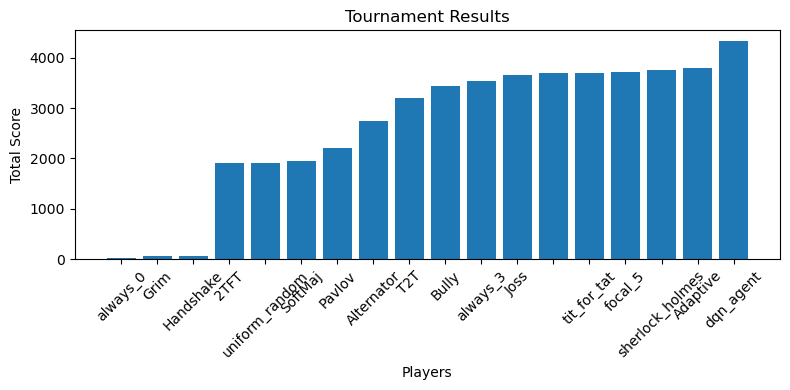

In [71]:
# Aquí probamos un torneo individual:

game = Game()

players = entrenadores
dqn_agent = DQNAgent(game, "dqn_agent")

all_players = (*players, dqn_agent)

tournament = Tournament(all_players, n_rounds=100, error=0.01, repetitions=1)
tournament.play()
tournament.plot_results()

Cuando completes tu estrategia, súbela a Moodle. Aunque la práctica se desarrolle en grupo, **cada miembro del grupo debe hacer su entrega individualmente**. Nombra el archivo que subas como "P1 - [Nombres y apellidos personas del grupo]" (por ejemplo "P1 - [Juan Álvarez y Rosa Ruiz].ipynb)".

## Consideraciones logísticas sobre la práctica
- Asegúrate que el código funciona correctamente antes de entregarlo. En particular, asegúrate de que tu estrategias siempre devuelve una acción, independientemente de cómo sea la historia de la interacción. Así mismo, asegúrate de que el código está programado con un buen estilo.
En particular, utiliza *type hints*, documenta los métodos que escribas, y comenta las secciones relevantes del código.

- Debéis desarrollar el código vosotros mismos, no utilizar código ya disponible (online o en librerías). Los trabajos de los grupos que no hayan desarrollado el código ellos mismos, o que hayan pasado su código a otras personas, serán evaluados con un 0.

- Esta hoja de trabajo incluye todos los conceptos necesarios para desarrollar la práctica. Si tienes alguna pregunta, no dudes en utilizar las tutorías del curso para resolverla. Hay muchísima bibliografía online sobre juegos de coordinación y bargaining, aunque en absoluto es necesario consultarla: las dinámicas de cada campeonato dependen fuertemente de las personas que participan en él. Lo realmente útil es que pienses en qué tipo de estrategias crees que van a presentar tus rivales y hagas suficientes pruebas.

- Si trabajas en proyecto, puedes compartirlo como zip o mediante link de github.
  
- No se aceptarán entregas fuera de plazo.


## Rúbrica de calificación de la práctica

PARTE 1:
 - **[3.5/10] Funcionamiento del código**: el código descrito en la *Parte 1* de la práctica debe funcionar correctamente, sin *bugs*, permitiendo reproducir todas las funcionalidades descritas.
 - **[2/10] Limpieza y claridad de estilo**: el código debe estar bien escrito, siguiendo la guía de estilo PEP 8.
  
PARTE 2:
 - **[1/10] Implementación de una estrategia correcta**: que funcione sin errores y que esté programada con claridad.
 - **[3.5/10] Originalidad de la estrategia y trabajo de exploración llevado a cabo**: el tipo de estrategia presentada, junto con las explicaciones que hayas aportado en comentarios y demás, pondrá de manifiesto el trabajo de experimentación que has llevado a cabo con tu estrategia. Este item pretende evaluar este aspecto.
  
EXTRAS:
 - **[1.5 puntos] extras al ganador del campeonato**

## Bibliografía: 

-**ChatGPT y Gemini**: El entendimiento profundo de los conceptos abordados y de las técnicas aplicadas se ha visto reforzado gracias a las explicaciones detalladas ofrecidas por estos modelos de inteligencia artificial. Asimismo, han sido de gran ayuda en la detección y corrección de errores y en la mejora de la estructura y limpieza del código. En ningún caso se ha realizado un uso acrítico o un copia–pega sin comprensión previa del contenido.

-https://ncase.me/trust/